## Homework 2: Models for Regression

#### Air Quality Prediction (NO2)

#### **Objetivo:** Desenvolver modelos de regressão para calibrar sensores de baixo custo e prever a concentração de Dióxido de Nitrogênio (NO₂).

### 1. Configurações Iniciais
- **Objetivo da seção:** preparar ambiente, bibliotecas e diretórios para execução reprodutível.
- **Escopo:** instalar/acionar dependências, ajustar visual e definir semente fixa para garantir comparabilidade dos resultados.

#### 1.1 Importando Bibliotecas
- **Modelagem:** `LinearRegression`, `Ridge/RidgeCV`, `PLSRegression` para regressões base e penalizada.
- **Validação:** `train_test_split`, `cross_val_score` para separação e CV.
- **Métricas:** `mean_squared_error`, `r2_score` para RMSE e R².
- **Utilidades:** `numpy`, `pandas`, `matplotlib`, `seaborn`, avisos suprimidos e semente fixa para reprodutibilidade.

In [17]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy --quiet 

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Python312\Scripts\pip.exe\__main__.py", line 4, in <module>
ModuleNotFoundError: No module named 'pip'


In [18]:
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.neural_network import MLPRegressor
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore
from sklearn import random as sk_random
from random import seed as random_seed
from sklearn.utils import check_random_state

#### 1.2 Configurações visuais e diretório para salvar imagens
- **Visual:** temas claros, figuras maiores e grid para leitura rápida.
- **Persistência:** `PATH_FIG` centraliza salvamento de figuras para posterior uso em relatório.
- **Reprodutibilidade:** `SEED=42` sincroniza aleatoriedade em todas as etapas (split, CV, modelos).

In [19]:
# Configurações Visuais
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6)})

# Diretório para salvar imagens
PATH_FIG = "./figures"
os.makedirs(PATH_FIG, exist_ok=True)

def savefig(name): return plt.savefig(os.path.join(
    PATH_FIG, f"{name}.png"), bbox_inches="tight")
# add seed 42
SEED = 42
random_seed(SEED)
np.random.seed(SEED)
rng = check_random_state(SEED)

In [20]:
# Caracterização do Conjunto de Dados
# Carrega dados brutos para calcular missing
air_quality_raw = pd.read_csv(data_path, sep=";", decimal=",", na_values=-200)
n_obs_raw = air_quality_raw.shape[0]
# Após limpeza
n_obs_clean = air_quality.shape[0]
# Período (assumindo conhecimento do dataset UCI)
periodo = "2004-2005"
# Lista de sensores e variáveis
# Sensores: PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2), PT08.S5(O3)
# Variáveis meteorológicas: T (Temperatura), RH (Umidade Relativa), AH (Umidade Absoluta)
sensores = "PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2), PT08.S5(O3)"
meteorologicas = "T (Temperatura), RH (Umidade Relativa), AH (Umidade Absoluta)"
# Assimetria
# Skewness do target e principais preditores
skew_target = air_quality['NO2(GT)'].skew()
# Principais preditores com alta skew (exemplo)
high_skew = air_quality.select_dtypes(include=[np.number]).skew()
principais_skew = high_skew[abs(high_skew) > 0.75].sort_values(ascending=False).head(3).to_dict()
# Percentual de missing removido
missing_removed_pct = ((n_obs_raw - n_obs_clean) / n_obs_raw) * 100
# Tabela
caracterizacao_df = pd.DataFrame({
    'Característica': [
        'Número de observações após limpeza',
        'Período da coleta',
        'Sensores utilizados',
        'Variáveis meteorológicas',
        'Assimetria do target (NO₂)',
        'Principais preditores com alta assimetria (|skew| > 0.75)',
        'Percentual de missing removido (%)'
    ],
    'Valor': [
        f'{n_obs_clean}',
        periodo,
        sensores,
        meteorologicas,
        f'{skew_target:.2f}',
        ', '.join([f'{k}: {v:.2f}' for k, v in principais_skew.items()]),
        f'{missing_removed_pct:.2f}'
    ]
})
caracterizacao_df.to_dict()

{'Característica': {0: 'Número de observações após limpeza',
  1: 'Período da coleta',
  2: 'Sensores utilizados',
  3: 'Variáveis meteorológicas',
  4: 'Assimetria do target (NO₂)',
  5: 'Principais preditores com alta assimetria (|skew| > 0.75)',
  6: 'Percentual de missing removido (%)'},
 'Valor': {0: '827',
  1: '2004-2005',
  2: 'PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2), PT08.S5(O3)',
  3: 'T (Temperatura), RH (Umidade Relativa), AH (Umidade Absoluta)',
  4: '0.07',
  5: 'NMHC(GT): 1.49, CO(GT): 1.07, C6H6(GT): 1.00',
  6: '91.27'}}

#### 1.3 Loading e limpeza inicial
- Fonte: `air_quality_uci.csv` (UCI), separador `;`, vírgula como decimal.
- Limpeza: remove colunas vazias e descarta linhas com `NaN` para evitar imputações ad hoc.

In [21]:
# Loading Dataset
data_path = "../database/air_quality_uci.csv"
air_quality = pd.read_csv(data_path, sep=";", decimal=",", na_values=-200)

# Limpeza inicial dos dados
air_quality = air_quality.iloc[:, :-2]  # Remove colunas vazias
air_quality.dropna(inplace=True)        # Remove linhas com NaN

print(f"Dataset Carregado: {air_quality.shape}")

Dataset Carregado: (827, 15)


#### 1.4 Temporal e outliers
- **Exploração temporal:** avalia estabilidade da série de NO₂ e possíveis tendências/sazonalidades.
- **Distribuições e outliers:** boxplots normalizados para comparar escalas e localizar valores extremos que podem distorcer ajustes.

=== Tabela de Estatística Descritiva ===


,count,mean,std,min,25%,50%,75%,max
CO(GT),827.0,2.35,1.41,0.3,1.30,2.00,3.10,8.10
PT08.S1(CO),827.0,1207.88,241.82,753.0,1017.00,1172.00,1380.00,2040.00
NMHC(GT),827.0,231.03,208.46,7.0,77.00,157.00,318.50,1189.00
C6H6(GT),827.0,10.77,7.42,0.5,4.80,9.10,14.80,39.20
PT08.S2(NMHC),827.0,966.12,266.42,448.0,754.00,944.00,1142.50,1754.00
NOx(GT),827.0,143.50,81.83,12.0,81.00,128.00,187.00,478.00
PT08.S3(NOx),827.0,963.30,265.91,461.0,769.00,920.00,1131.00,1935.00
NO2(GT),827.0,100.26,31.49,19.0,78.50,99.00,122.00,196.00
PT08.S4(NO2),827.0,1600.62,302.29,955.0,1369.50,1556.00,1783.50,2679.00
PT08.S5(O3),827.0,1045.81,400.13,263.0,760.00,1009.00,1320.00,2359.00


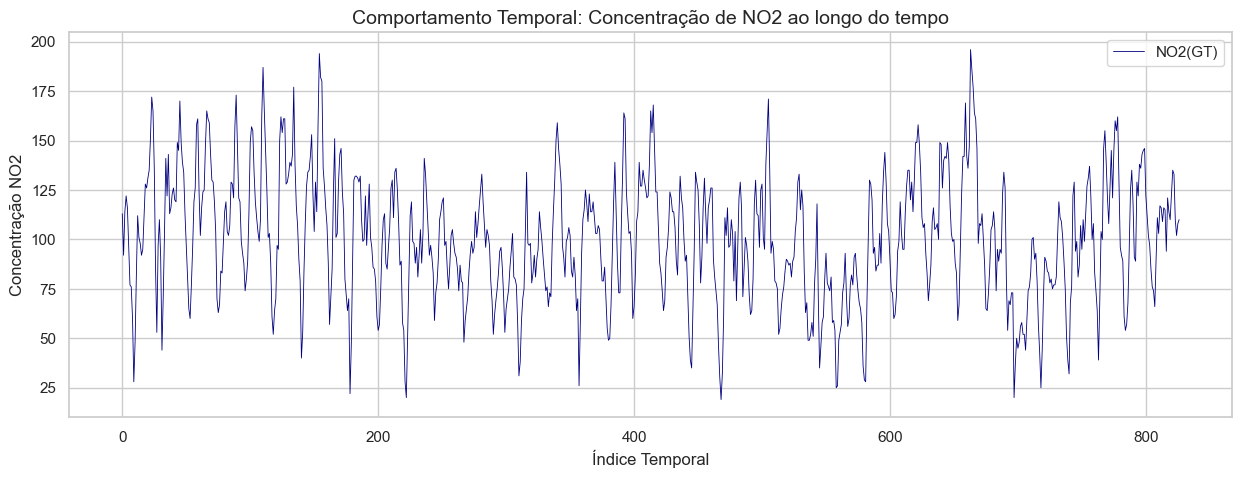

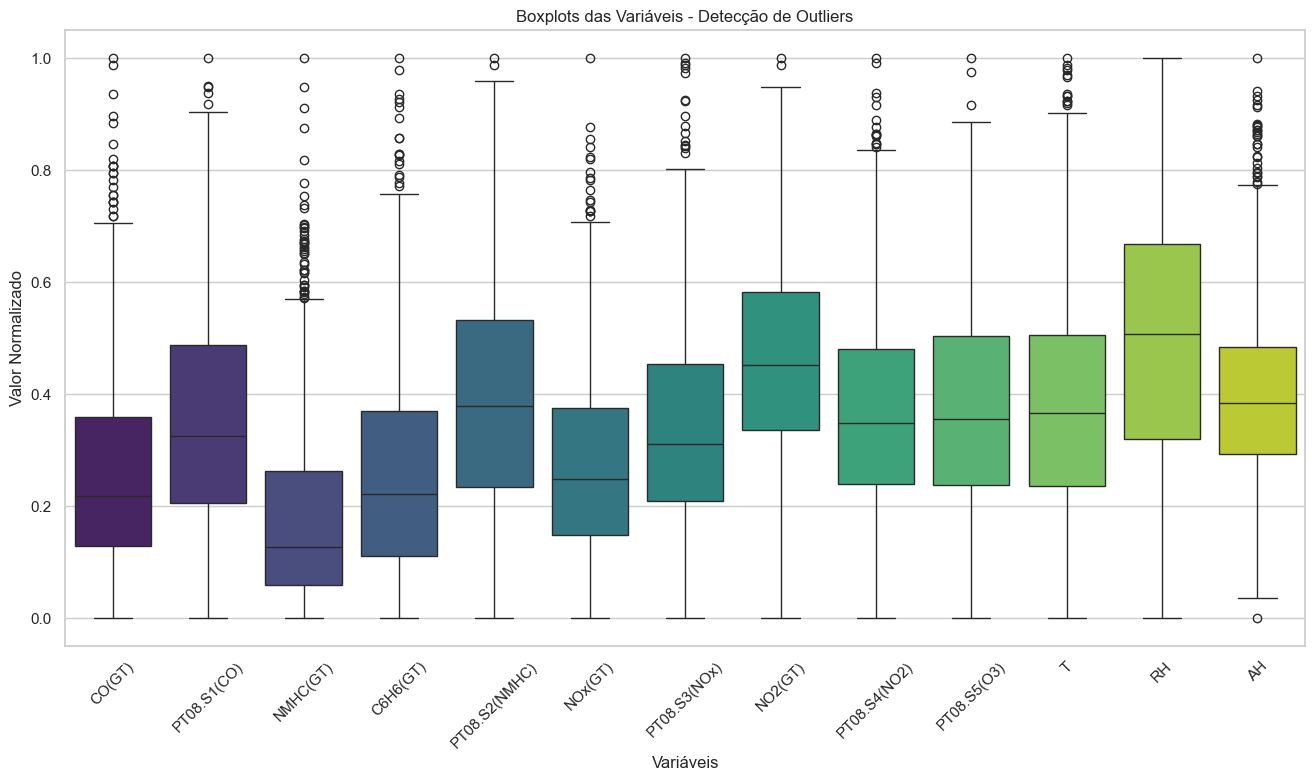

In [22]:
print("=== Tabela de Estatística Descritiva ===")
display(air_quality.describe().T.round(2))

# Comportamento Temporal (Target NO2)
plt.figure(figsize=(15, 5))
if not np.issubdtype(air_quality.index.dtype, np.datetime64):
    x_axis = range(len(air_quality))
else:
    x_axis = air_quality.index

plt.plot(x_axis, air_quality["NO2(GT)"],
         label="NO2(GT)", color='navy', linewidth=0.6)
plt.title(
    "Comportamento Temporal: Concentração de NO2 ao longo do tempo", fontsize=14)
plt.xlabel("Índice Temporal")
plt.ylabel("Concentração NO2")
plt.legend()
savefig("eda_temporal_behavior")
plt.show()

# Boxplots e Análise de Outliers
# Seleciona apenas colunas numéricas
df_numeric = air_quality.select_dtypes(include=[np.number])

# Normalização Min-Max para visualização
df_norm_viz = (df_numeric - df_numeric.min()) / \
    (df_numeric.max() - df_numeric.min())

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_norm_viz, palette="viridis")
plt.xticks(rotation=45)
plt.title("Boxplots das Variáveis - Detecção de Outliers")
plt.xlabel("Variáveis")
plt.ylabel("Valor Normalizado")
savefig("eda_boxplots_outliers")
plt.show()

### 2. Definição de Variáveis e Split
- **Alvo (Y):** `NO2(GT)`.
- **Preditores (X):** sensores e clima numéricos.
- **Princípio:** separar rótulo de preditores antes de qualquer transformação para manter clareza e evitar vazamento.

#### 2.1 Separação X e Y

In [23]:
TARGET_COL = "NO2(GT)"

# Seleção de colunas para preditores
numeric_cols = air_quality.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != TARGET_COL]
X = air_quality[feature_cols]
y = air_quality[TARGET_COL]

print(f"Target: {TARGET_COL}")
print(f"Preditores ({len(feature_cols)}): {feature_cols}")

Target: NO2(GT)
Preditores (12): ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


#### 2.2 Divisão Treino e Teste
- Split 75/25 com `random_state=42`.
- Feito **antes** de normalizar para prevenir data leakage e avaliar generalização em dados totalmente não vistos.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (620, 12)
Teste:  (207, 12)


### 3. Pré-processamento
- **Problema:** distribuições assimétricas e escalas distintas prejudicam modelos lineares.
- **Solução:** log1p nas variáveis com |skew|>0.75 e padronização Z-score ajustada apenas no treino; aplicar no teste e CV para evitar vazamento.

#### 3.1 Skewness e Normalização
##### Aplicamos transformação Logarítmica nas variáveis assimétricas e Normalização Z-Score.
##### Calculamos os parâmetros (média, desvio) apenas no Treino e aplicamos no Teste.

**Nota de pré-processamento:** log + z-score são ajustados somente nos dados de treino e aplicados no teste e nas CV, evitando data leakage.

In [25]:
def process_data(X_train_raw, X_test_raw):
    X_tr = X_train_raw.copy()
    X_ts = X_test_raw.copy()  # Copia para não alterar original

    # Tratamento de Skewness (Log1p)
    skewness = X_tr.skew()
    high_skew_cols = skewness[abs(skewness) > 0.75].index

    print(
        f"Colunas com alta assimetria (Log transform): {list(high_skew_cols)}")

    for col in high_skew_cols:
        min_val = min(X_tr[col].min(), X_ts[col].min())
        offset = 0
        if min_val <= 0:
            offset = abs(min_val) + 1

        X_tr[col] = np.log1p(X_tr[col] + offset)
        X_ts[col] = np.log1p(X_ts[col] + offset)

    # Normalização Z-Score (Fit no Train, Transform no Test)
    train_mean = X_tr.mean()
    train_std = X_tr.std()

    X_tr_norm = (X_tr - train_mean) / train_std
    X_ts_norm = (X_ts - train_mean) / train_std

    return X_tr_norm, X_ts_norm

# Aplica a função
X_train_norm, X_test_norm = process_data(X_train, X_test)

Colunas com alta assimetria (Log transform): ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'PT08.S3(NOx)']


### 3.2 Visualização do Impacto do Pré-processamento
- Comparação antes/depois em variável assimétrica para verificar redução de skew e escala.
- Checagem visual ajuda a validar se log + z-score aproximam normalidade para modelos lineares.

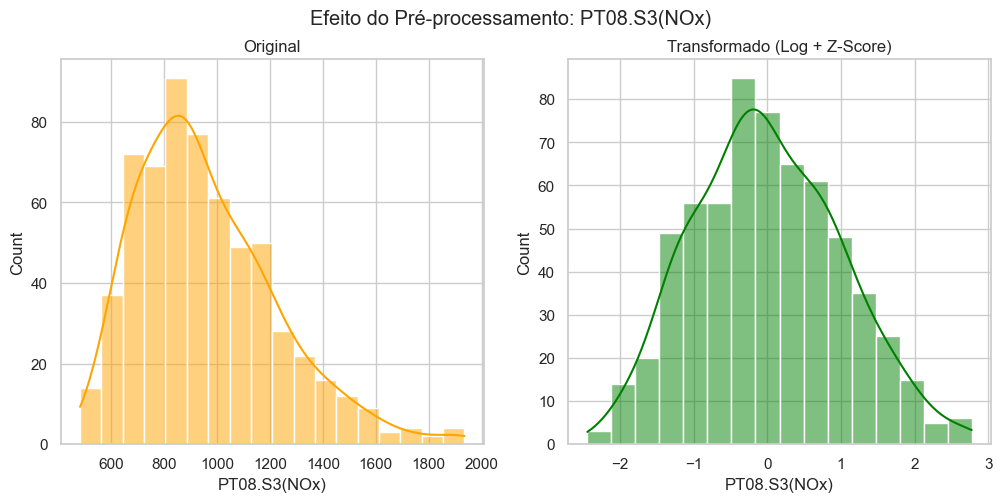

In [26]:
col_check = "PT08.S3(NOx)"  # Exemplo de variável geralmente assimétrica

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(X_train[col_check], kde=True, ax=ax[0],
             color="orange").set_title("Original")
sns.histplot(X_train_norm[col_check], kde=True, ax=ax[1],
             color="green").set_title("Transformado (Log + Z-Score)")
plt.suptitle(f"Efeito do Pré-processamento: {col_check}")
plt.show()

### 4. Análise de Correlação e Linearidade
- **Objetivo:** entender relações lineares entre preditores e NO₂.
- **Ferramentas:** heatmap (com máscara superior) e ranking das maiores correlações com o alvo.
- **Uso:** orientar intuição sobre variáveis relevantes e possíveis multicolinearidades.

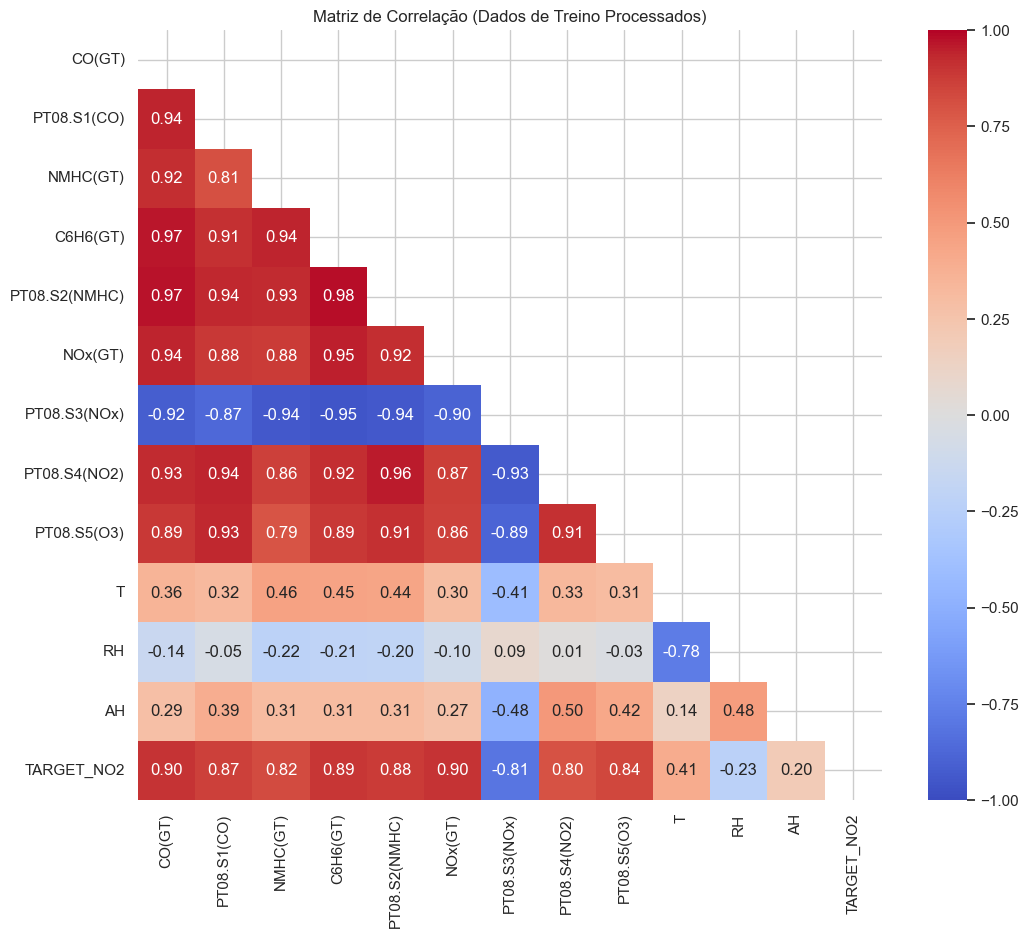

CO(GT)           0.904538
NOx(GT)          0.900596
C6H6(GT)         0.891888
PT08.S2(NMHC)    0.881931
PT08.S1(CO)      0.866645
PT08.S5(O3)      0.838444
NMHC(GT)         0.821965
PT08.S4(NO2)     0.803828
T                0.405686
AH               0.202118
RH              -0.230321
PT08.S3(NOx)    -0.810441
Name: TARGET_NO2, dtype: float64


In [27]:
# Heatmap de Correlação
train_full = X_train_norm.copy()
train_full['TARGET_NO2'] = y_train

plt.figure(figsize=(12, 10))
corr = train_full.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", mask=mask, vmin=-1, vmax=1)
plt.title("Matriz de Correlação (Dados de Treino Processados)")
plt.show()

# Correlações Top com Target
print(corr['TARGET_NO2'].drop('TARGET_NO2').sort_values(ascending=False))

### 5. Implementação de Regressão Linear (OLS)
- Derivada da equação normal $\beta = (X^T X)^{-1} X^T y$.
- Classe manual permite observar coeficientes e comparar com biblioteca.
- Ajustada após padronização para que magnitudes sejam comparáveis.

In [28]:
class LinearRegressionOLS_Manual:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values     # Converte para numpy array se for DataFrame para álgebra matricial

        # Adiciona coluna de 1s para o intercepto (Bias)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Equação Normal: inv(X.T * X) * X.T * y
        try:
            theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(
                X_b.T).dot(y)  # Tenta inversa normal antes
        except np.linalg.LinAlgError:
            # Usa pseudo-inversa se a matriz for singular (determinante = 0)
            theta_best = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

        self.intercept_ = theta_best[0]
        self.coef_ = theta_best[1:]

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return X.dot(self.coef_) + self.intercept_

print("Classe OLS Manual compilada com sucesso.")

Classe OLS Manual compilada com sucesso.


### 6. Comparação de modelos (Manual vs Scikit-Learn)
- Compara implementação manual OLS com `LinearRegression` para validar corretude.
- Métricas: RMSE e R² no teste; gráfico real vs predito evidencia erros sistemáticos.

**Modelo 1 (OLS):** implementação manual (equação normal) e `LinearRegression` do sklearn.

**Modelo 2 (Ridge):** regressão linear penalizada L2, com seleção de $\lambda$ por CV (10 folds).

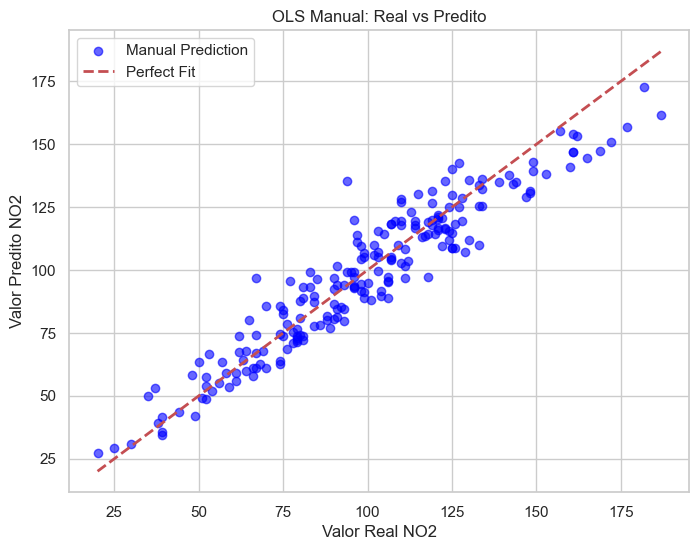

In [29]:
# Modelo Manual
ols_manual = LinearRegressionOLS_Manual()
ols_manual.fit(X_train_norm, y_train)
y_pred_manual = ols_manual.predict(X_test_norm)

# Modelo Scikit-Learn
ols_sklearn = LinearRegression()
ols_sklearn.fit(X_train_norm, y_train)
y_pred_sklearn = ols_sklearn.predict(X_test_norm)

# Função auxiliar de Métricas
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

rmse_man, r2_man = evaluate(y_test, y_pred_manual, "Manual")
rmse_skl, r2_skl = evaluate(y_test, y_pred_sklearn, "Sklearn")

# Visualização Gráfica
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_manual, alpha=0.6,
            color='blue', label='Manual Prediction')
plt.plot([y_test.min(), y_test.max()], [y_test.min(),
         y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Valor Real NO2")
plt.ylabel("Valor Predito NO2")
plt.title("OLS Manual: Real vs Predito")
plt.legend()
savefig("ols_manual_vs_real")
plt.show()

### 7. Validação Cruzada (Cross-Validation)
- **Por que:** estimar desempenho médio e variabilidade, evitando overfitting ao teste.
- **Como:** K-Fold manual e `cross_val_score` (10 folds) para RMSE/R².
- **Leituras gráficas:** boxplot e perfis por fold mostram dispersão de erro e estabilidade.

### 7.1 Implementação manual da Cross-Validation
#### Implementamos manualmente o K-Fold CV. Criamos o loop que:
#### 1. Embaralha os dados.
#### 2. Divide em K partes.
#### 3. Itera K vezes, usando uma parte para teste e o resto para treino.

In [30]:
def k_fold_cv_manual(model_class, X, y, k=10, model_kwargs=None):
    X = X.values if isinstance(X, pd.DataFrame) else X
    y = y.values if isinstance(y, pd.Series) else y
    n_samples = len(X)
    fold_size = n_samples // k
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    metrics = {"rmse": [], "r2": []}
    for i in range(k):
        start, end = i * fold_size, (i + 1) * fold_size
        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        X_f_train, y_f_train = X[train_idx], y[train_idx]
        X_f_val, y_f_val = X[val_idx], y[val_idx]
        model = model_class(**(model_kwargs or {}))
        model.fit(X_f_train, y_f_train)
        y_f_pred = model.predict(X_f_val)
        rmse = np.sqrt(mean_squared_error(y_f_val, y_f_pred))
        r2 = r2_score(y_f_val, y_f_pred)
        metrics["rmse"].append(rmse)
        metrics["r2"].append(r2)
    return metrics

cv_results = k_fold_cv_manual(LinearRegressionOLS_Manual, X_train_norm, y_train, k=10)

cv_rmse_sklearn = -cross_val_score(
    LinearRegression(),
    X_train_norm,
    y_train,
    cv=10,
    scoring='neg_root_mean_squared_error'
).mean()

cv_r2_sklearn = cross_val_score(
    LinearRegression(),
    X_train_norm,
    y_train,
    cv=10,
    scoring='r2'
).mean()

results_df = pd.DataFrame({
    "Modelo": [
        "OLS Manual (From Scratch)",
        "OLS Sklearn (Built-in)",
        "Cross-Validation Manual (10 Folds)",
        "Cross-Validation Sklearn (10 Folds)"
    ],
    "RMSE": [
        rmse_man,
        rmse_skl,
        np.mean(cv_results['rmse']),
        cv_rmse_sklearn
    ],
    "R2 Score": [
        r2_man,
        r2_skl,
        np.mean(cv_results['r2']),
        cv_r2_sklearn
    ]
})

metrics = results_df.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")
metrics

,Modelo,Métrica,Valor
0,OLS Manual (From Scratch),RMSE,10.403632
1,OLS Sklearn (Built-in),RMSE,10.403632
2,Cross-Validation Manual (10 Folds),RMSE,10.799466
3,Cross-Validation Sklearn (10 Folds),RMSE,10.931799
4,OLS Manual (From Scratch),R2 Score,0.896244
5,OLS Sklearn (Built-in),R2 Score,0.896244
6,Cross-Validation Manual (10 Folds),R2 Score,0.874645
7,Cross-Validation Sklearn (10 Folds),R2 Score,0.872322


### 7.2 Perfil da Cross-Validation
#### O boxplot mostra a variação do erro (RMSE) ao longo dos folds.

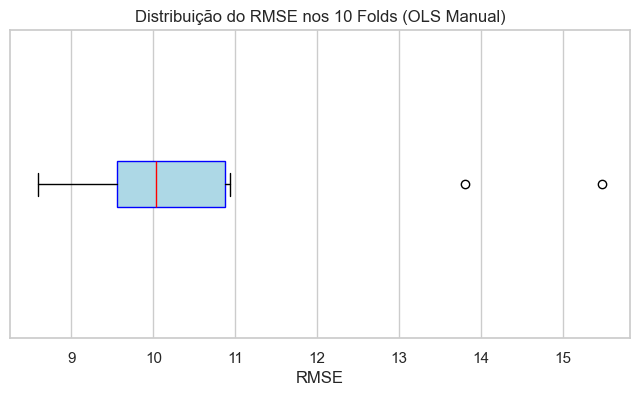

In [31]:
plt.figure(figsize=(8, 4))
plt.boxplot(cv_results['rmse'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red"))
plt.title("Distribuição do RMSE nos 10 Folds (OLS Manual)")
plt.xlabel("RMSE")
plt.yticks([])
savefig("ols_cv_boxplot")
plt.show()

### Gráfico de linha apresenta variação de RMSE por fold.

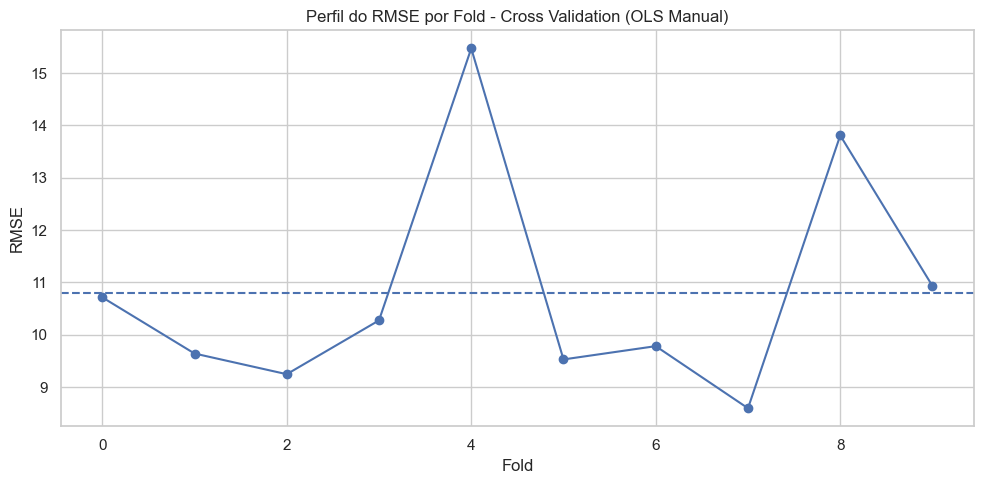

In [32]:
rmse_values = cv_results['rmse']

plt.figure(figsize=(10,5))
plt.plot(rmse_values, marker='o')
plt.axhline(np.mean(rmse_values), linestyle='--')
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Perfil do RMSE por Fold - Cross Validation (OLS Manual)")
plt.tight_layout()
plt.show()

### Gráfico de linha apresenta variação de R² por fold.

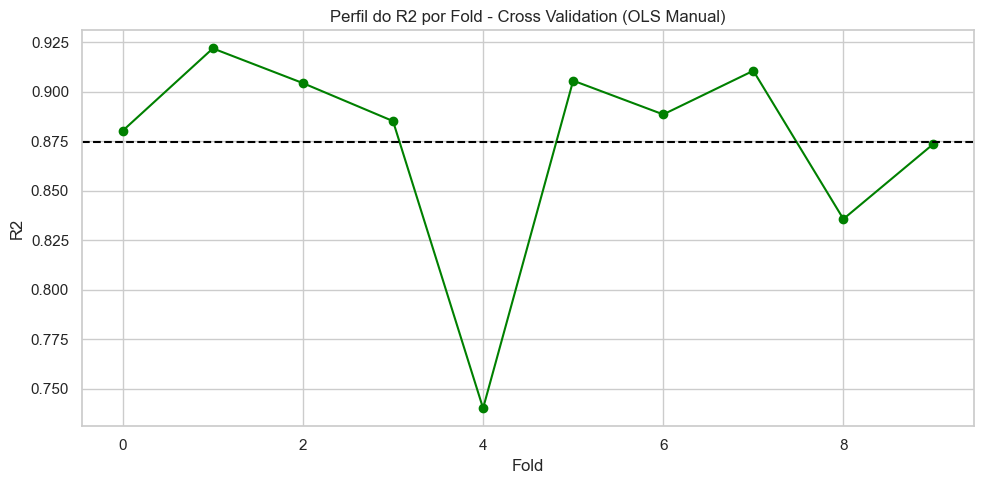

In [33]:
r2_values = cv_results['r2']

plt.figure(figsize=(10,5))
plt.plot(r2_values, marker='o', color='green')
plt.axhline(np.mean(r2_values), linestyle='--', color='black')
plt.xlabel("Fold")
plt.ylabel("R2")
plt.title("Perfil do R2 por Fold - Cross Validation (OLS Manual)")
plt.tight_layout()
plt.show()

### 8. Regressão Penalizada (Ridge)
- **Motivação:** reduzir variância e mitigar multicolinearidade penalizando coeficientes.
- **Busca de $\lambda$:** grade logarítmica em 10 valores, escolhendo menor RMSE médio em 10 folds.
- **Comparação:** implementação manual vs `Ridge/RidgeCV` para validar pipeline e resultados.

**Modelo 2 (Ridge):** regressão linear penalizada L2, selecionando $\lambda$ por CV (10 folds) e comparando implementação manual vs `Ridge/RidgeCV`. 

In [34]:
class RidgeRegressionManual:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        y_arr = y.values if isinstance(y, pd.Series) else y
        X_b = np.c_[np.ones((X_arr.shape[0], 1)), X_arr]
        identity = np.eye(X_b.shape[1])
        identity[0, 0] = 0  # não penaliza intercepto
        ridge_matrix = X_b.T @ X_b + self.alpha * identity
        theta = np.linalg.pinv(ridge_matrix) @ X_b.T @ y_arr
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

    def predict(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return X_arr @ self.coef_ + self.intercept_


#### 8.1 Seleção de $\lambda$ com validação cruzada (10 folds)
Buscamos o melhor $\lambda$ em uma grade logarítmica (10 valores) usando RMSE médio dos folds; também acompanhamos o R².

In [35]:
lambda_grid = np.logspace(-3, 3, 10)
cv_summary = []
for lam in lambda_grid:
    cv_res = k_fold_cv_manual(RidgeRegressionManual, X_train_norm, y_train, k=10, model_kwargs={"alpha": lam})
    cv_summary.append({
        "lambda": lam,
        "rmse_mean": np.mean(cv_res["rmse"]),
        "rmse_std": np.std(cv_res["rmse"]),
        "r2_mean": np.mean(cv_res["r2"]),
        "r2_std": np.std(cv_res["r2"])
    })
ridge_cv_df = pd.DataFrame(cv_summary)
best_row = ridge_cv_df.loc[ridge_cv_df["rmse_mean"].idxmin()]
best_lambda_manual = best_row["lambda"]


#### 8.2 Perfil da validação cruzada (RMSE e R²)
Visualizamos o comportamento das métricas ao variar $\lambda$ (escala log).

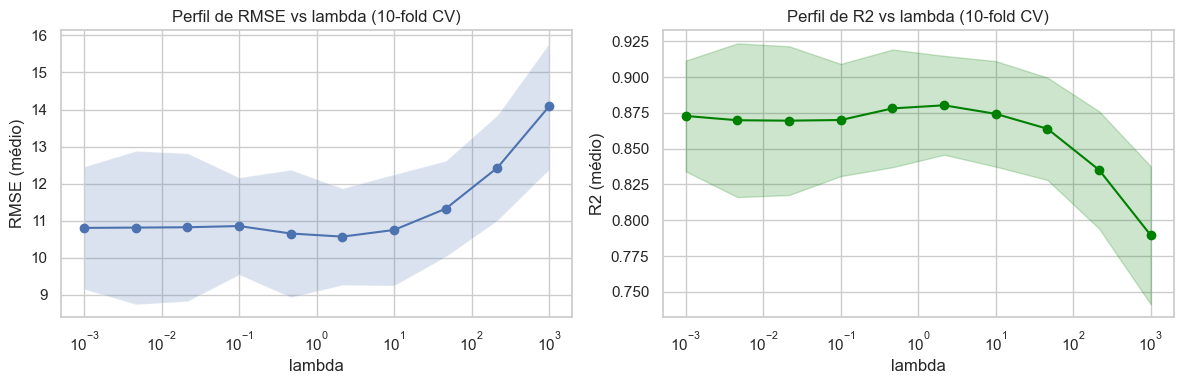

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ridge_cv_df["lambda"], ridge_cv_df["rmse_mean"], marker="o")
ax[0].fill_between(ridge_cv_df["lambda"], ridge_cv_df["rmse_mean"] - ridge_cv_df["rmse_std"], ridge_cv_df["rmse_mean"] + ridge_cv_df["rmse_std"], alpha=0.2)
ax[0].set_xscale("log")
ax[0].set_xlabel("lambda")
ax[0].set_ylabel("RMSE (médio)")
ax[0].set_title("Perfil de RMSE vs lambda (10-fold CV)")
ax[1].plot(ridge_cv_df["lambda"], ridge_cv_df["r2_mean"], marker="o", color="green")
ax[1].fill_between(ridge_cv_df["lambda"], ridge_cv_df["r2_mean"] - ridge_cv_df["r2_std"], ridge_cv_df["r2_mean"] + ridge_cv_df["r2_std"], alpha=0.2, color="green")
ax[1].set_xscale("log")
ax[1].set_xlabel("lambda")
ax[1].set_ylabel("R2 (médio)")
ax[1].set_title("Perfil de R2 vs lambda (10-fold CV)")
plt.tight_layout()
savefig("ridge_cv_profile")
plt.show()


#### 8.3 Ajuste final e comparação (manual vs sklearn)
Usamos o melhor $\lambda$ obtido na CV manual e comparamos com `RidgeCV` do sklearn usando a mesma grade.

In [37]:
# Modelo manual com melhor lambda
ridge_manual_best = RidgeRegressionManual(alpha=best_lambda_manual)
ridge_manual_best.fit(X_train_norm, y_train)
y_pred_ridge_manual = ridge_manual_best.predict(X_test_norm)
rmse_ridge_manual, r2_ridge_manual = evaluate(y_test, y_pred_ridge_manual, "Ridge Manual")

# Modelo sklearn com mesma grade
ridge_cv = RidgeCV(alphas=lambda_grid, cv=10, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train_norm, y_train)
best_lambda_sklearn = ridge_cv.alpha_
ridge_sklearn = Ridge(alpha=best_lambda_sklearn, random_state=SEED)
ridge_sklearn.fit(X_train_norm, y_train)
y_pred_ridge_sklearn = ridge_sklearn.predict(X_test_norm)
rmse_ridge_sklearn, r2_ridge_sklearn = evaluate(y_test, y_pred_ridge_sklearn, "Ridge Sklearn")

cv_rmse_ridge_skl = -cross_val_score(Ridge(alpha=best_lambda_sklearn), X_train_norm, y_train, cv=10, scoring='neg_root_mean_squared_error').mean()
cv_r2_ridge_skl = cross_val_score(Ridge(alpha=best_lambda_sklearn), X_train_norm, y_train, cv=10, scoring='r2').mean()

ridge_results_df = pd.DataFrame({
    "Modelo": [
        "Ridge Manual (best CV)",
        "Ridge Sklearn (best CV)"
    ],
    "Lambda": [best_lambda_manual, best_lambda_sklearn],
    "RMSE Teste": [rmse_ridge_manual, rmse_ridge_sklearn],
    "R2 Teste": [r2_ridge_manual, r2_ridge_sklearn],
    "RMSE CV (10-fold)": [best_row["rmse_mean"], cv_rmse_ridge_skl],
    "R2 CV (10-fold)": [best_row["r2_mean"], cv_r2_ridge_skl]
})
ridge_results_df

,Modelo,Lambda,RMSE Teste,R2 Teste,RMSE CV (10-fold),R2 CV (10-fold)
0,Ridge Manual (best CV),2.154435,10.464948,0.895018,10.567846,0.880259
1,Ridge Sklearn (best CV),2.154435,10.464948,0.895018,10.756799,0.877137


#### 8.4 Observações
- O melhor $\lambda$ manual e do sklearn podem diferir, mas os resultados devem ser próximos.
- O RMSE/R² de teste usa o modelo ajustado com o $\lambda$ ótimo encontrado apenas no treino (boas práticas de generalização).
- O perfil de CV ilustra a estabilidade das métricas ao variar a penalização.

### 9. Regressão por Componentes Parciais (PLS)
- **Por que PLS:** componentes supervisionados maximizam covariância entre X e Y, úteis com muitos preditores correlacionados.
- **Fluxo:** pré-processamento (log+z-score) → seleção de componentes por CV → ajuste final → avaliação em teste.

#### 9.1 Seleção do número de componentes (10-fold CV)
- Grade: 1 até 15 componentes (limitado pelo nº de features).
- Critério: menor RMSE médio em 10 folds, acompanhando R² para estabilidade.
- Resultado: `best_components_pls` armazena o número ótimo para o ajuste final.

In [38]:
components_grid = list(range(1, min(15, X_train_norm.shape[1]) + 1))
k_folds_pls = 10
pls_cv_summary = []
for n_comp in components_grid:
    cv_res = k_fold_cv_manual(
        PLSRegression,
        X_train_norm,
        y_train,
        k=k_folds_pls,
        model_kwargs={"n_components": n_comp}
    )
    pls_cv_summary.append({
        "n_components": n_comp,
        "rmse_mean": np.mean(cv_res["rmse"]),
        "rmse_std": np.std(cv_res["rmse"]),
        "r2_mean": np.mean(cv_res["r2"]),
        "r2_std": np.std(cv_res["r2"])
    })
pls_cv_df = pd.DataFrame(pls_cv_summary)
best_pls_row = pls_cv_df.loc[pls_cv_df["rmse_mean"].idxmin()]
best_components_pls = int(best_pls_row["n_components"])
pls_cv_df

,n_components,rmse_mean,rmse_std,r2_mean,r2_std
0,1,13.881556,1.327391,0.796603,0.037464
1,2,12.756961,1.616067,0.826970,0.045085
2,3,12.155996,1.859530,0.834644,0.067360
3,4,11.205441,0.732782,0.860161,0.041480
4,5,10.861080,1.226793,0.870797,0.039026
5,6,10.656882,1.466544,0.873558,0.045203
6,7,10.702521,1.575719,0.874087,0.040297
7,8,10.713899,0.948460,0.873569,0.047026
8,9,10.642892,1.596597,0.876887,0.037322
9,10,10.864664,1.732809,0.868438,0.060653


#### 9.2 Perfil da validação cruzada (RMSE e R²)
- Gráficos RMSE/R² vs. componentes mostram trade-off entre erro e explicação.
- Faixas de incerteza (desvio padrão) indicam variabilidade entre folds.

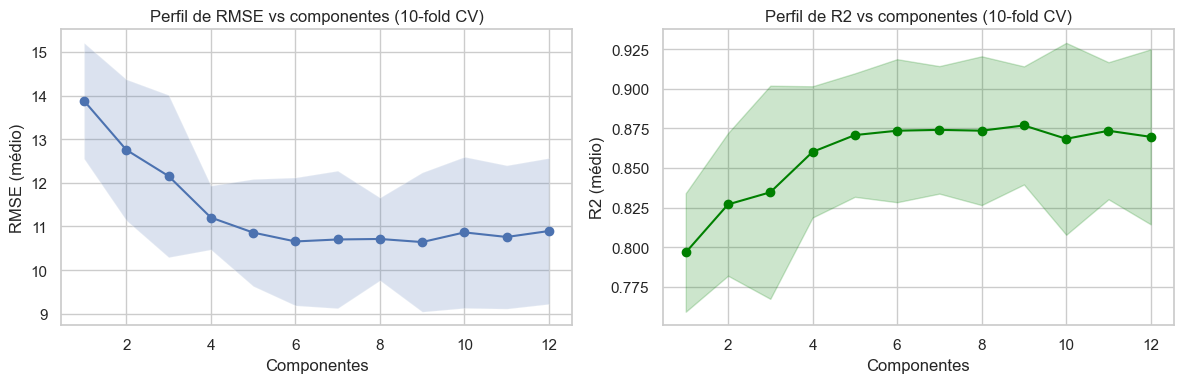

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(pls_cv_df["n_components"], pls_cv_df["rmse_mean"], marker="o")
ax[0].fill_between(
    pls_cv_df["n_components"],
    pls_cv_df["rmse_mean"] - pls_cv_df["rmse_std"],
    pls_cv_df["rmse_mean"] + pls_cv_df["rmse_std"],
    alpha=0.2
)
ax[0].set_xlabel("Componentes")
ax[0].set_ylabel("RMSE (médio)")
ax[0].set_title("Perfil de RMSE vs componentes (10-fold CV)")
ax[1].plot(pls_cv_df["n_components"], pls_cv_df["r2_mean"], marker="o", color="green")
ax[1].fill_between(
    pls_cv_df["n_components"],
    pls_cv_df["r2_mean"] - pls_cv_df["r2_std"],
    pls_cv_df["r2_mean"] + pls_cv_df["r2_std"],
    alpha=0.2,
    color="green"
)
ax[1].set_xlabel("Componentes")
ax[1].set_ylabel("R2 (médio)")
ax[1].set_title("Perfil de R2 vs componentes (10-fold CV)")
plt.tight_layout()
savefig("pls_cv_profile")
plt.show()

In [40]:
pls_best = PLSRegression(n_components=best_components_pls)
pls_best.fit(X_train_norm, y_train)
y_pred_pls_test = pls_best.predict(X_test_norm).ravel()
rmse_pls_test, r2_pls_test = evaluate(y_test, y_pred_pls_test, "PLS (best)")

pls_results_df = pd.DataFrame({
    "Modelo": ["PLSRegression (best CV)"],
    "Componentes": [best_components_pls],
    "RMSE Teste": [rmse_pls_test],
    "R2 Teste": [r2_pls_test],
    "RMSE CV (10-fold)": [best_pls_row["rmse_mean"]],
    "R2 CV (10-fold)": [best_pls_row["r2_mean"]]
})
pls_results_df

,Modelo,Componentes,RMSE Teste,R2 Teste,RMSE CV (10-fold),R2 CV (10-fold)
0,PLSRegression (best CV),9,10.441786,0.895482,10.642892,0.876887


#### 9.3 Visualização da Projeção PLS
- Projeta dados no primeiro componente PLS (supervisionado) e compara real vs predito.
- Linhas de regressão esperada/predita destacam coerência e possíveis vieses.

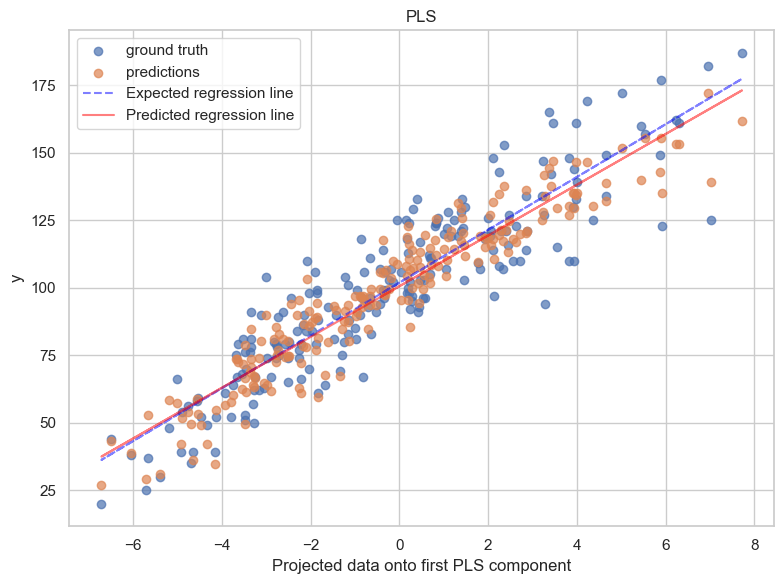

In [41]:
# Usar o PLS já treinado com melhor número de componentes
pls_vis = pls_best

proj = pls_vis.transform(X_test_norm)[:, 0]
y_pred = pls_vis.predict(X_test_norm).ravel()

# Linha de regressão para ground truth
slope_gt, intercept_gt = np.polyfit(proj, y_test, 1)
line_gt = slope_gt * proj + intercept_gt

# Linha de regressão para predictions
slope_pred, intercept_pred = np.polyfit(proj, y_pred, 1)
line_pred = slope_pred * proj + intercept_pred

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(proj, y_test, alpha=0.7, label="ground truth")
ax.scatter(proj, y_pred, alpha=0.7, label="predictions")
ax.plot(proj, line_gt, color='blue', alpha=0.5, linestyle='--', label='Expected regression line')
ax.plot(proj, line_pred, color='red', alpha=0.5, linestyle='-', label='Predicted regression line')
ax.set(xlabel="Projected data onto first PLS component", ylabel="y", title="PLS")
ax.legend()
plt.tight_layout()
savefig("pls_projection")
plt.show()

#### 9.4 Scatter Plot – Valores Reais vs. Preditos (Teste)
- Avalia generalização no conjunto de teste.
- Pontos próximos à linha de 45° indicam bom ajuste; padrões de dispersão sugerem viés ou heterocedasticidade.

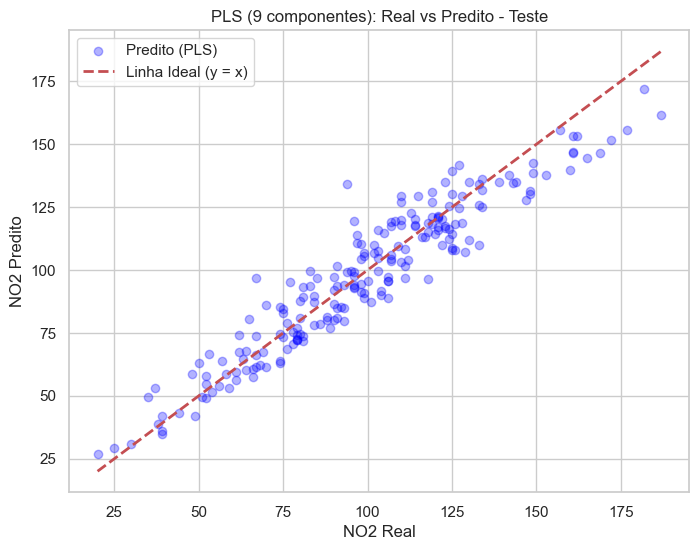

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_pls_test, alpha=0.3, color="blue", label="Predito (PLS)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Linha Ideal (y = x)')
plt.xlabel("NO2 Real")
plt.ylabel("NO2 Predito")
plt.title(f"PLS ({best_components_pls} componentes): Real vs Predito - Teste")
plt.legend()
savefig("pls_real_vs_pred")
plt.show()


#### 9.5 Gráfico de Cargas dos Componentes Supervisionados
Mostra as cargas (loadings) das variáveis originais no primeiro componente PLS.
Indica importância relativa de cada preditor na projeção supervisionada.

,Variável,Carga
0,CO(GT),0.332670
1,PT08.S1(CO),0.322140
2,NMHC(GT),0.319677
3,C6H6(GT),0.335926
4,PT08.S2(NMHC),0.337284
5,NOx(GT),0.320450
6,PT08.S3(NOx),-0.329143
7,PT08.S4(NO2),0.326270
8,PT08.S5(O3),0.315990
9,T,0.155641


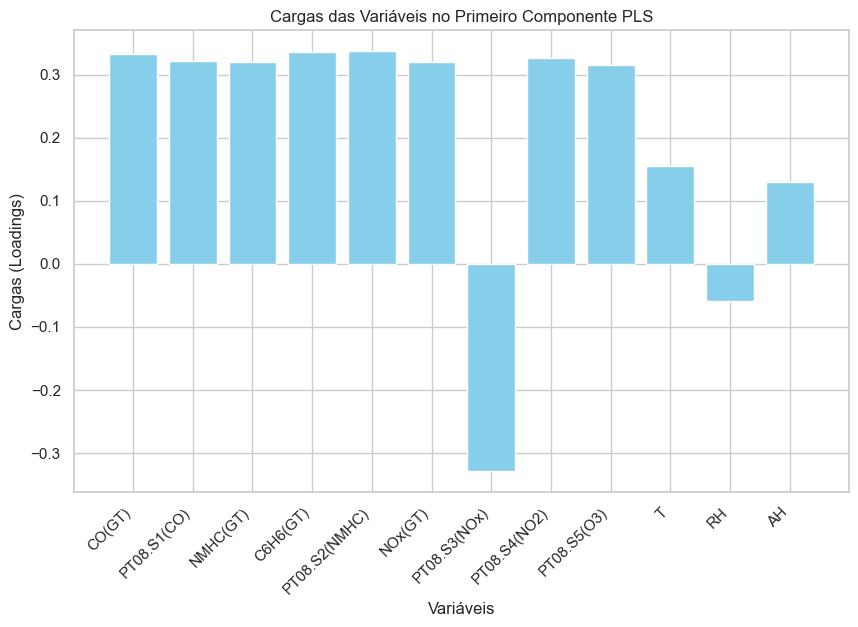

In [43]:
loadings = pls_best.x_loadings_[:, 0]  # Cargas do primeiro componente
loadings_df = pd.DataFrame({'Variável': feature_cols, 'Carga': loadings})
display(loadings_df)
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_cols)), loadings, color='skyblue')
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha='right')
plt.xlabel('Variáveis')
plt.ylabel('Cargas (Loadings)')
plt.title('Cargas das Variáveis no Primeiro Componente PLS')
savefig('pls_loadings')
plt.show()

### 10. Rede Neural (MLP)
- Camada densa única (`MLPRegressor`) sobre `X_train_norm`/`X_test_norm`, mantendo o mesmo pré-processamento.
- Métricas no teste: RMSE e R² para comparar com OLS/Ridge/PLS.
- Use a saída para avaliar se a não linearidade melhora o ajuste.

In [44]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    max_iter=800,
    random_state=SEED,
    early_stopping=True,
    n_iter_no_change=20
 )
mlp_reg.fit(X_train_norm, y_train)
y_pred_mlp = mlp_reg.predict(X_test_norm)
rmse_mlp, r2_mlp = evaluate(y_test, y_pred_mlp, "MLP")
mlp_results = pd.DataFrame({
    "Modelo": ["OLS Sklearn", "MLP (1 hidden)", "Ridge Sklearn", "PLS (best CV)"],
    "RMSE Teste": [rmse_skl, rmse_mlp, rmse_ridge_sklearn, rmse_pls_test],
    "R2 Teste": [r2_skl, r2_mlp, r2_ridge_sklearn, r2_pls_test]
})
mlp_results

,Modelo,RMSE Teste,R2 Teste
0,OLS Sklearn,10.403632,0.896244
1,MLP (1 hidden),13.217788,0.832521
2,Ridge Sklearn,10.464948,0.895018
3,PLS (best CV),10.441786,0.895482


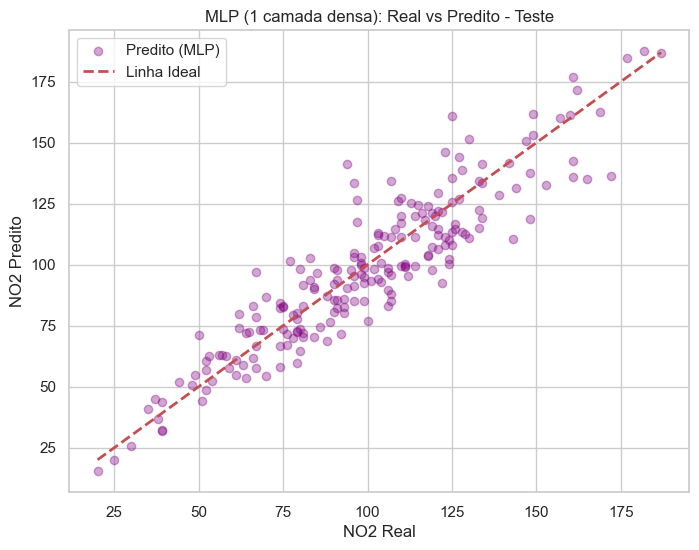

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.35, color="purple", label="Predito (MLP)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Linha Ideal")
plt.xlabel("NO2 Real")
plt.ylabel("NO2 Predito")
plt.title("MLP (1 camada densa): Real vs Predito - Teste")
plt.legend()
savefig("mlp_real_vs_pred")
plt.show()

**Interpretação:** compare RMSE/R² do MLP com OLS/Ridge/PLS na tabela acima. Caso o MLP reduza o RMSE e aumente o R², há evidência de relação não linear entre preditores e NO₂; se não, modelos lineares já capturam a estrutura dominante.

### 11. Comparação de Desempenho dos Modelos

In [46]:
# Calcular CV para MLP
cv_rmse_mlp = -cross_val_score(MLPRegressor(hidden_layer_sizes=(64,), activation="relu", solver="adam", max_iter=800, random_state=SEED, early_stopping=True, n_iter_no_change=20), X_train_norm, y_train, cv=10, scoring='neg_root_mean_squared_error').mean()
cv_r2_mlp = cross_val_score(MLPRegressor(hidden_layer_sizes=(64,), activation="relu", solver="adam", max_iter=800, random_state=SEED, early_stopping=True, n_iter_no_change=20), X_train_norm, y_train, cv=10, scoring='r2').mean()

# Tabela 4 — Desempenho dos Modelos (Teste e CV)
desempenho_df = pd.DataFrame({
    "Modelo": ["OLS", "Ridge", "PLS", "MLP"],
    "RMSE_CV": [cv_rmse_sklearn, cv_rmse_ridge_skl, best_pls_row["rmse_mean"], cv_rmse_mlp],
    "R²_CV": [cv_r2_sklearn, cv_r2_ridge_skl, best_pls_row["r2_mean"], cv_r2_mlp],
    "RMSE_teste": [rmse_skl, rmse_ridge_sklearn, rmse_pls_test, rmse_mlp],
    "R²_teste": [r2_skl, r2_ridge_sklearn, r2_pls_test, r2_mlp]
})
desempenho_df

,Modelo,RMSE_CV,R²_CV,RMSE_teste,R²_teste
0,OLS,10.931799,0.872322,10.403632,0.896244
1,Ridge,10.756799,0.877137,10.464948,0.895018
2,PLS,10.642892,0.876887,10.441786,0.895482
3,MLP,13.564981,0.805638,13.217788,0.832521


In [57]:
# Tabela 5 — Importância das Variáveis (Coeficientes Padronizados do Ridge)
coef_padronizados = ridge_sklearn.coef_ / X_train_norm.std()
importancia_df = pd.DataFrame({
    'Coeficiente Padronizado': coef_padronizados
}).sort_values('Coeficiente Padronizado', ascending=False)
print('Tabela 5 — Importância das Variáveis (Coeficientes Padronizados do Ridge)')
importancia_df

Tabela 5 — Importância das Variáveis (Coeficientes Padronizados do Ridge)


,Coeficiente Padronizado
PT08.S3(NOx),16.748656
NOx(GT),14.416744
CO(GT),11.568833
PT08.S2(NMHC),9.376075
PT08.S5(O3),9.037147
NMHC(GT),5.931285
PT08.S1(CO),5.775833
AH,3.901597
C6H6(GT),3.061783
T,1.409000
